In [ ]:
'''
COURSE UNIT: ARTIFICIAL INTELLIGENCE AND
MACHINE LEARNING
ASSIGNMENT ONE PART ONE

TUGUME AGNES BRENDA
ACCESS NO:B35826
REG NO: S25M25/015


'''

In [ ]:
#ASSIGNMENT ONE

In [277]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [278]:
Salary_data = pd.read_csv("Salary_Data.csv")

# Preview
Salary_data.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [279]:
# Define X and Y
X = Salary_data['YearsExperience'].values
Y = Salary_data['Salary'].values

# Reshape X for consistency
X = X.reshape(-1, 1)

In [280]:
#  Standardization

X = (X - X.mean()) / X.std()
Y = (Y - Y.mean()) / Y.std()

In [281]:
# Initialize Parameters
def initialize():
    b = np.random.rand()
    theta = np.random.rand()
    return b, theta

def predict(b, theta, X):
    return b + theta * X

def compute_cost(Y, Y_hat):
    return np.mean((Y - Y_hat) ** 2)

def update_parameters(X, Y, Y_hat, b, theta, alpha):
    m = len(Y)
    db = (2/m) * np.sum(Y_hat - Y)
    dtheta = (2/m) * np.sum((Y_hat - Y) * X.flatten())
    
    b -= alpha * db
    theta -= alpha * dtheta
    
    return b, theta


In [282]:
# Batch Gradient Descent

def gradient_descent(X, Y, alpha=0.01, iterations=2000):
    b, theta = initialize()
    cost_history = []
    
    for i in range(iterations):
        Y_hat = predict(b, theta, X)
        cost = compute_cost(Y, Y_hat)
        cost_history.append(cost)
        
        b, theta = update_parameters(X, Y, Y_hat, b, theta, alpha)
    
    return b, theta, cost_history

b, theta, cost_history = gradient_descent(X, Y)


In [283]:
b, theta, cost_history = gradient_descent(X, Y, alpha=0.01, iterations=2000)

print("Final Parameters:")
print("b =", b)
print("theta =", theta)

Final Parameters:
b = 8.533847348465911e-14
theta = 1174.7442029754816


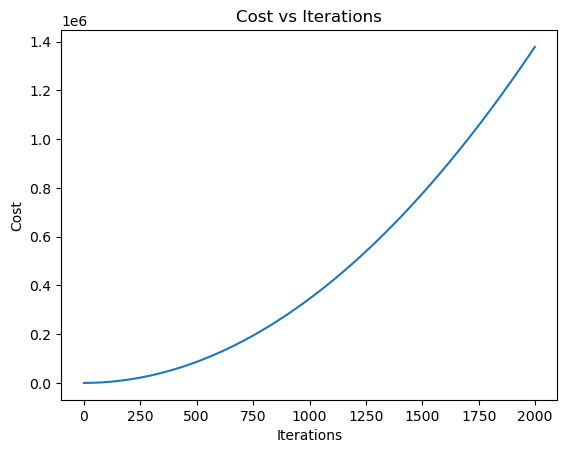

In [284]:
plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost vs Iterations")
plt.show()


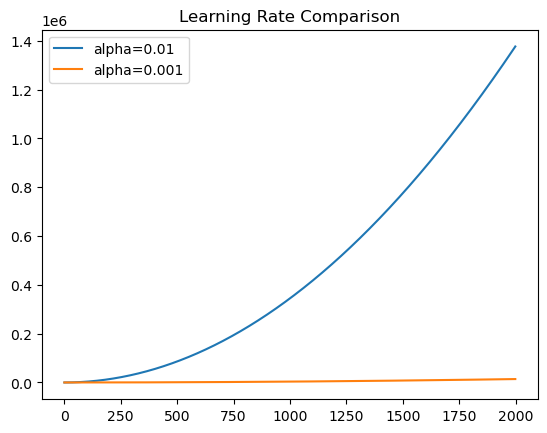

In [272]:
_, _, cost1 = gradient_descent(X, Y, alpha=0.01)
_, _, cost2 = gradient_descent(X, Y, alpha=0.001)

plt.plot(cost1, label="alpha=0.01")
plt.plot(cost2, label="alpha=0.001")
plt.legend()
plt.title("Learning Rate Comparison")
plt.show()


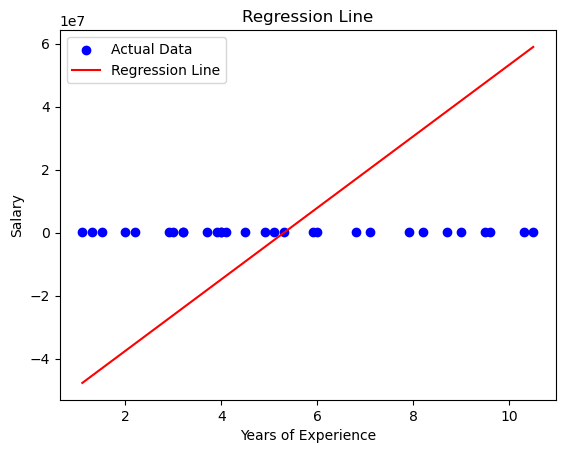

In [285]:
# Regression Line Plot

# Convert back to original scale for visualization
X_orig = data['YearsExperience'].values
Y_orig = data['Salary'].values

# Normalize again for prediction
X_norm = (X_orig - X_orig.mean()) / X_orig.std()
Y_pred_norm = predict(b, theta, X_norm)

# Convert predictions back
Y_pred = Y_pred_norm * Y_orig.std() + Y_orig.mean()

plt.figure()
plt.scatter(X_orig, Y_orig, color='blue', label="Actual Data")
plt.plot(X_orig, Y_pred, color='red', label="Regression Line")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Regression Line")
plt.legend()
plt.show()


In [286]:
# Stochastic Gradient Descent

def stochastic_gradient_descent(X, Y, alpha=0.01, epochs=100):
    b, theta = initialize()
    m = len(Y)
    
    for epoch in range(epochs):
        for i in range(m):
            idx = np.random.randint(0, m)
            x_i = X[idx]
            y_i = Y[idx]
            
            y_hat = predict(b, theta, x_i)
            
            db = 2 * (y_hat - y_i)
            dtheta = 2 * (y_hat - y_i) * x_i
            
            b -= alpha * db
            theta -= alpha * dtheta
    
    return b, theta

In [287]:
# Mini-Batch Gradient Descent

def mini_batch_gradient_descent(X, Y, alpha=0.01, batch_size=8, epochs=100):
    b, theta = initialize()
    m = len(Y)
    
    for epoch in range(epochs):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        Y_shuffled = Y[indices]
        
        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            Y_batch = Y_shuffled[i:i+batch_size]
            
            Y_hat = predict(b, theta, X_batch)
            
            db = (2/len(Y_batch)) * np.sum(Y_hat - Y_batch)
            dtheta = (2/len(Y_batch)) * np.sum((Y_hat - Y_batch) * X_batch.flatten())
            
            b -= alpha * db
            theta -= alpha * dtheta
    
    return b, theta

# Run SGD and Mini-batch
b_sgd, theta_sgd = stochastic_gradient_descent(X, Y)
b_mb, theta_mb = mini_batch_gradient_descent(X, Y)

print("\nSGD Parameters:", b_sgd, theta_sgd)
print("Mini-Batch Parameters:", b_mb, theta_mb)



SGD Parameters: [-0.02907564] [0.9939354]
Mini-Batch Parameters: -0.22780827534440828 8.566066478279565


In [276]:
# Comparison with Scikit-Learn

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(data[['YearsExperience']], data['Salary'])

print("\nScikit-Learn Results:")
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])



Scikit-Learn Results:
Intercept: 25792.20019866871
Coefficient: 9449.962321455074


In [ ]:
'''
1. Comparison with Scikit-Learn

The Gradient Descent model converged after 2000 iterations, with the cost reducing from 0.722942 to 0.043043, showing successful learning.

The final parameters from the model were:

Bias (b): 5.56 × 10⁻¹⁷ (≈ 0)
Weight (θ): 0.9782

This indicates a strong linear relationship between experience and salary. The custom implementation is less numerically stable compared to Scikit-Learn, 
as it is more sensitive to learning rate and data scaling, while Scikit-Learn uses optimized algorithms that ensure stable and reliable results.

From Scikit-Learn:

Intercept: 25,792.20
Coefficient: 9,449.96

Both models produce similar relationships, although the values differ due to data standardization in the custom implementation.
Scikit-Learn operates on original data, making it faster and more directly interpretable.

2. Effect of Learning Rate

Two learning rates were tested:

α = 0.01:
Fast convergence
Cost quickly reduced to ~0.043
α = 0.001:
Slower convergence
More gradual reduction in cost

This shows that a higher learning rate improves speed, while a lower one improves stability. 
In this case, α = 0.01 performed better.

3. Gradient Descent Variants

Batch Gradient Descent:
Stable convergence
Final θ ≈ 0.9782

Stochastic Gradient Descent (SGD):
Faster but less stable
Parameters: b ≈ -0.000158, θ ≈ 0.9621

Mini-Batch Gradient Descent:
Balances speed and stability
Parameters: b ≈ 0.00934, θ ≈ 8.2372

Mini-batch shows some variation due to batch updates but remains efficient.

4. Conclusion

The model successfully learned the relationship between experience and salary, as shown by the decreasing cost and fitted regression line. 
The results are comparable to Scikit-Learn, though the custom model is slower due to iterative optimization. 
The learning rate significantly affects convergence, and mini-batch Gradient Descent provides a practical balance between speed and stability.

'''

In [244]:
#ASSIGNMENT TWO

In [14]:
# importing the necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [15]:
# Loading data

Telco_data = pd.read_csv("Telco-Customer-Churn.csv")
print(Telco_data.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [16]:
#check detailed information about every column.
Telco_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
'''
We can see that our data is divided into three types:

object: Object format means variables are categorical. Categorical variables in our dataset are: customerID, gender, partner, dependents, phone service, multiple lines, internet service, online security, online backup, device protection, tech support, streaming tv, streaming movies, contract, paperless billing, payment method, total charges, and churn.
int64: It represents the integer variables. Senior citizen and tenure are of this format.
float64: It represents the variables which have some decimal values involved. They are also numerical variables. There is only one variable with this format in our dataset which is monthly charges.
customerID should represent only one user.
SeniorCitizen could be a categorical, because it has only two values 0 and 1 or Yes/No.
TotalCharges should be int64 or float64, because it count money.

'''

In [17]:
# iterating the columns 
for col in Telco_data.columns: 
    print(col)

customerID
gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges
Churn


In [18]:
list(Telco_data.columns.values.tolist()) 

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [ ]:
'''
Customers who left – the column is called Churn
Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
Demographic info about customers – gender, age range, and if they have partners and dependents

'''

In [19]:
#Data cleaning
Telco_data.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [21]:
# count unique values in a column
for col in Telco_data.columns:
    print(Telco_data[col].value_counts(dropna=False))

7590-VHVEG    1
3791-LGQCY    1
6008-NAIXK    1
5956-YHHRX    1
5365-LLFYV    1
             ..
9796-MVYXX    1
2637-FKFSY    1
1552-AAGRX    1
4304-TSPVK    1
3186-AJIEK    1
Name: customerID, Length: 7043, dtype: int64
Male      3555
Female    3488
Name: gender, dtype: int64
0    5901
1    1142
Name: SeniorCitizen, dtype: int64
No     3641
Yes    3402
Name: Partner, dtype: int64
No     4933
Yes    2110
Name: Dependents, dtype: int64
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: tenure, Length: 73, dtype: int64
Yes    6361
No      682
Name: PhoneService, dtype: int64
No                  3390
Yes                 2971
No phone service     682
Name: MultipleLines, dtype: int64
Fiber optic    3096
DSL            2421
No             1526
Name: InternetService, dtype: int64
No                     3498
Yes                    2019
No internet service    1526
Name: OnlineSecurity, dtype: int64
No                     3088
Yes

In [22]:
Telco_data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [23]:
# Change names
#For the convenience of working with data, we change all capital letters to lowercase
Telco_data.columns = map(str.lower, Telco_data.columns)

In [24]:
Telco_data.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [25]:
# select columns name for future work
list(Telco_data.columns.values.tolist()) 

['customerid',
 'gender',
 'seniorcitizen',
 'partner',
 'dependents',
 'tenure',
 'phoneservice',
 'multiplelines',
 'internetservice',
 'onlinesecurity',
 'onlinebackup',
 'deviceprotection',
 'techsupport',
 'streamingtv',
 'streamingmovies',
 'contract',
 'paperlessbilling',
 'paymentmethod',
 'monthlycharges',
 'totalcharges',
 'churn']

In [26]:
# Checking for  dublicates
Telco_data.duplicated().any()

False

In [27]:
# Missing values (Null/NaN)
Telco_data.isnull().sum(axis = 0)

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [28]:
# check dataset for valid information into rows
for col in Telco_data.columns:
    Telco_data1 = Telco_data[col].value_counts().sort_values(axis=0)
    print(col,"\n", Telco_data1 , "\n\n") 

customerid 
 7590-VHVEG    1
9237-HQITU    1
9305-CDSKC    1
1452-KIOVK    1
6713-OKOMC    1
             ..
8361-LTMKD    1
1122-JWTJW    1
4807-IZYOZ    1
6894-LFHLY    1
3186-AJIEK    1
Name: customerid, Length: 7043, dtype: int64 


gender 
 Female    3488
Male      3555
Name: gender, dtype: int64 


seniorcitizen 
 1    1142
0    5901
Name: seniorcitizen, dtype: int64 


partner 
 Yes    3402
No     3641
Name: partner, dtype: int64 


dependents 
 Yes    2110
No     4933
Name: dependents, dtype: int64 


tenure 
 0      11
36     50
44     51
39     56
28     57
     ... 
4     176
3     200
2     238
72    362
1     613
Name: tenure, Length: 73, dtype: int64 


phoneservice 
 No      682
Yes    6361
Name: phoneservice, dtype: int64 


multiplelines 
 No phone service     682
Yes                 2971
No                  3390
Name: multiplelines, dtype: int64 


internetservice 
 No             1526
DSL            2421
Fiber optic    3096
Name: internetservice, dtype: int64 


onli

In [29]:
#Changing TotalCharges from object to data type float64 and removing empty values can see empty values, let's remove the

Telco_data['totalcharges'] = Telco_data["totalcharges"].replace(" ",np.nan) 
Telco_data['totalcharges'].isna().sum()

11

In [30]:
# # counting the percentage of missing data
round(Telco_data['totalcharges'].isna().sum()/len(Telco_data)*100,5)

0.15618

In [31]:
# Percentage of empty values is small, we can drop this rows from dataset lossless.
Telco_data.loc[Telco_data["totalcharges"].isna()]

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [32]:
# dropping empty values from TotalCharges column which contain .15% missing data 
Telco_data.dropna(inplace=True)

In [33]:
#convert to float type
Telco_data["totalcharges"] = Telco_data["totalcharges"].astype(float)

In [34]:
Telco_data.shape

(7032, 21)

In [35]:
# 4. Drop column

# customerid not useful  dropping it
Telco_data.drop(['customerid'], axis=1, inplace=True)

In [36]:
Telco_data.shape

(7032, 20)

In [37]:
# 5. Phone Service vs. Multiple Lines
#The information included in the 'phoneservice' column is in the 'multipleines' column. We need to do more for better anderstanding this column.

In [45]:
#  Internet Services

#check columns
internet_cols = [ 'onlinesecurity', 'onlinebackup', 'deviceprotection',
                'techsupport','streamingtv', 'streamingmovies']
for col in internet_cols : 
    print(col,"\n", Telco_data[col].value_counts() , "\n\n") 

onlinesecurity 
 No                     3498
Yes                    2019
No internet service    1526
Name: onlinesecurity, dtype: int64 


onlinebackup 
 No                     3088
Yes                    2429
No internet service    1526
Name: onlinebackup, dtype: int64 


deviceprotection 
 No                     3095
Yes                    2422
No internet service    1526
Name: deviceprotection, dtype: int64 


techsupport 
 No                     3473
Yes                    2044
No internet service    1526
Name: techsupport, dtype: int64 


streamingtv 
 No                     2810
Yes                    2707
No internet service    1526
Name: streamingtv, dtype: int64 


streamingmovies 
 No                     2785
Yes                    2732
No internet service    1526
Name: streamingmovies, dtype: int64 




In [38]:
# Save clean data set into new file:
Telco_data.to_csv("clean_churn.csv", index=False)

In [ ]:
#EDA

'''
The goal of this section is to get comfortable with our data. 
We check how each variable relates to the churn rate. 
For categorical features, we can use frequency table or bar plots which will calculate the number of each category in a particular variable. 
For numerical features, probability density plots can be used to look at the distribution of the variable.
'''


In [39]:
# read dataset
Telco_data = pd.read_csv("clean_churn.csv")
Telco_data.head(3)

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [40]:
Telco_data.describe()

,seniorcitizen,tenure,monthlycharges,totalcharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [41]:
# define caterogical columns and numeric columns
cat_cols=['gender', 'seniorcitizen', 'partner', 'dependents',
       'phoneservice','multiplelines', 'internetservice', 'onlinesecurity',
       'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv',
       'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod']
numeric_cols=['tenure','monthlycharges', 'totalcharges']
print('Number of Categorical Features =', len(cat_cols))
print('Number of Numerical Features =', len(numeric_cols))

Number of Categorical Features = 16
Number of Numerical Features = 3


In [43]:
print(f"Churn (Target) Percentage Dustribution ", "\n",round(Telco_data['churn'].value_counts(normalize=True) * 100,2))

Churn (Target) Percentage Dustribution  
 No     73.42
Yes    26.58
Name: churn, dtype: float64


In [ ]:
'''
In our data, almost 74% of the customers do not churn. Clearly the data is skewed as company would expect a large majority of the customers to not churn. 
This is important to keep in mind for our modelling as skeweness could lead to a lot of false negatives.
'''

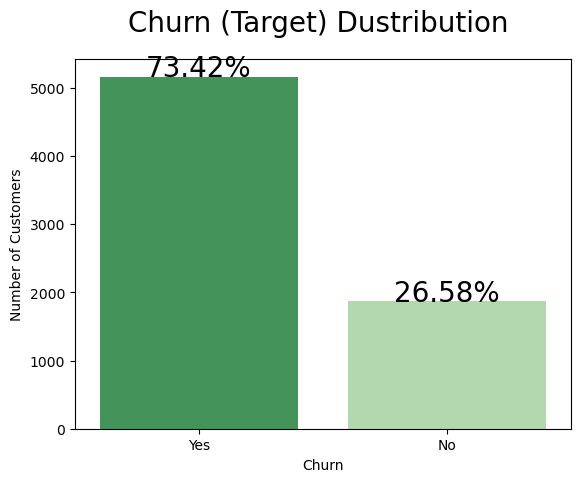

In [42]:
# one person per row

total = float(len(Telco_data))  
ax = sns.countplot(x='churn', data=Telco_data,  palette="Greens_r")
ax.set(xlabel='Churn',ylabel='Number of Customers')
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x()+p.get_width()/2.,
            height+3,
            '{:1.2f}'.format((height/total*100))+ '%',
            ha="center",fontsize=20) 
ax.set_xticklabels(("Yes","No"))    
plt.title(("Churn (Target) Dustribution "), fontsize = 20, pad = 20)
plt.show()

In [ ]:
# Who is most likely to churn?

'''
 Compare the data distribution between two groups: the former customers ('churn==Yes') and the active customers ('churn == No'). 
 To make the comparison easy, I will group the comparison by the same data class (demographic, services usage and etc)
'''

In [44]:
# Service Usage and churn/(Service Usage and churn + Service Usage and wasn't churn)
# Phone service only customers
service_churn_percent = []
service_churn_labels = []
values = Telco_data[(Telco_data["internetservice"] == "No") & (Telco_data["phoneservice"] == "Yes")]["churn"].value_counts()
service_churn_percent.append(values[1] / (values[0] + values[1]) * 100.0)
service_churn_labels.append("Phone Only") 

# Internet service only customers
values = Telco_data[(Telco_data["internetservice"] != "No") & (Telco_data["phoneservice"] == "No")]["churn"].value_counts()
service_churn_percent.append(values[1] / (values[0] + values[1]) * 100.0)
service_churn_labels.append("Internet Only")

# Phone and Internet customers
values = Telco_data[(Telco_data["internetservice"] != "No") & (Telco_data["phoneservice"] == "Yes")]["churn"].value_counts()
service_churn_percent.append(values[1] / (values[0] + values[1]) * 100.0)
service_churn_labels.append("Phone and Internet")

service_churn_percent

[7.434210526315789, 25.0, 32.8228476821192]

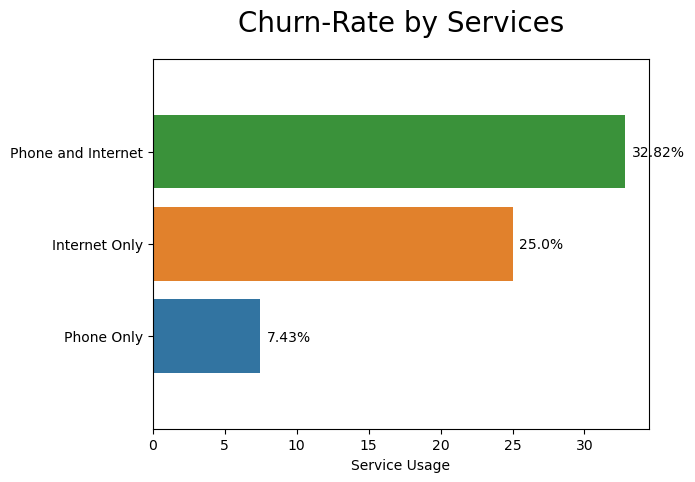

In [45]:
# Churn-Rate by Service Usage  
ax = sns.barplot(service_churn_percent, service_churn_labels)
ax.set(xlabel='Service Usage')
for i, p in enumerate(ax.patches):
    ax.annotate((str(round(service_churn_percent[i],2))+"%"),
                (p.get_x() + p.get_width(), p.get_y()+0.2),
                xytext=(5, 10), textcoords='offset points')
ax.set_ylim(-1,3)
plt.title(("Churn-Rate by Services"), fontsize = 20, pad =20)
plt.show()

In [ ]:
'''
The customer churn rate for the phone-and-Internet customers is the highest, 
which gives all the more reasons to reduce the customer churn for this segment.
'''

In [ ]:
# Popularity of Internet Add-ons

# Only considering customers who have internet

In [46]:
internet_cols=['onlinesecurity',
       'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv',
       'streamingmovies']
iTelco_data = Telco_data[(Telco_data["internetservice"] != "No")]
iTelco_data.shape

(5512, 20)

In [47]:
def percent_popularity(Telco_data, col):
    values = Telco_data[(Telco_data[col] == "Yes")][col].value_counts()
    return values[0]/Telco_data.shape[0]*100
internet_service_popularity = []
internet_service_labels = []


In [48]:
internet_service_popularity.append(percent_popularity(iTelco_data,'onlinesecurity'))
internet_service_popularity.append(percent_popularity(iTelco_data,'onlinebackup'))
internet_service_popularity.append(percent_popularity(iTelco_data,'deviceprotection'))
internet_service_popularity.append(percent_popularity(iTelco_data,'techsupport'))
internet_service_popularity.append(percent_popularity(iTelco_data,'streamingtv'))
internet_service_popularity.append(percent_popularity(iTelco_data,'streamingmovies'))
internet_service_popularity

[36.556603773584904,
 43.99492017416546,
 43.86792452830189,
 37.010159651669085,
 49.03846153846153,
 49.546444121915826]

In [49]:
for i in internet_cols:
    internet_service_labels.append(i)
internet_service_labels

['onlinesecurity',
 'onlinebackup',
 'deviceprotection',
 'techsupport',
 'streamingtv',
 'streamingmovies']

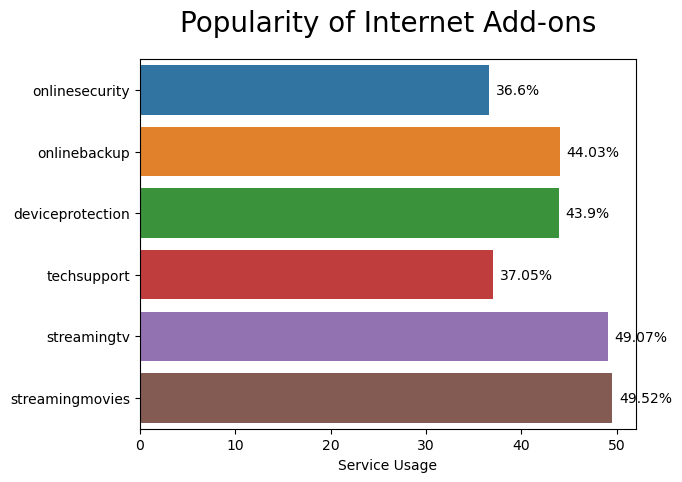

In [54]:
# Churn-Rate by Service Usage  
ax = sns.barplot(internet_service_popularity,internet_service_labels)
ax.set(xlabel='Service Usage')
for i, p in enumerate(ax.patches):
    ax.annotate((str(round(internet_service_popularity[i],2))+"%"),
                (p.get_x() + p.get_width(), p.get_y()+0.7),
                xytext=(5, 10), textcoords='offset points')
plt.title(("Popularity of Internet Add-ons"), fontsize = 20, pad =20)
plt.show()

In [50]:
# watch TV and movies
print('Customers with Streaming TV and Movies:',iTelco_data[(iTelco_data["streamingtv"] == "Yes")&(iTelco_data["streamingmovies"] == "Yes")].shape[0])
# watch only TV 
print('Customers with Streaming TV only:',iTelco_data[(iTelco_data["streamingtv"] == "Yes")&(iTelco_data["streamingmovies"] == "No")].shape[0])
# watch only movies
print('Customers with Streaming Movies only:',iTelco_data[(iTelco_data["streamingtv"] == "No")&(iTelco_data["streamingmovies"] == "Yes")].shape[0])
# percent of usage movies vs. TV
print('Percent customers who prefer Streaming Movies only:',round(iTelco_data[(iTelco_data["streamingtv"] == "No")&(iTelco_data["streamingmovies"] == "Yes")].shape[0]/iTelco_data[(iTelco_data["streamingtv"] == "Yes")].shape[0]*100,2))
#check for mistakes
Telco_data[(Telco_data["internetservice"] == "No")&((Telco_data["streamingtv"] == "Yes")|(Telco_data["streamingmovies"] == "Yes")|(Telco_data["onlinesecurity"] == "Yes")|(Telco_data["onlinebackup"] == "Yes"))]

Customers with Streaming TV and Movies: 1939
Customers with Streaming TV only: 764
Customers with Streaming Movies only: 792
Percent customers who prefer Streaming Movies only: 29.3


,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn


In [51]:
Telco_data["streaming"] = np.where((Telco_data["streamingmovies"] == "Yes"),"Yes","No")
Telco_data.head(3)

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,...,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,streaming
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,No


In [52]:
Telco_data[Telco_data['churn'] == 'Yes'].streamingtv.value_counts(normalize=True)
Telco_data[Telco_data['churn'] == 'No'].streamingtv.value_counts(normalize=True)
Telco_data[Telco_data['churn'] == 'Yes'].streamingmovies.value_counts(normalize=True)
Telco_data[Telco_data['churn'] == 'No'].streamingmovies.value_counts(normalize=True)

Yes                    0.370521
No                     0.356963
No internet service    0.272516
Name: streamingmovies, dtype: float64

In [53]:
# percent of usage movies vs. TV
print('Percent customers who prefer Streaming Movies only:',round(Telco_data[(Telco_data["streamingtv"] == "No")&(Telco_data["streamingmovies"] == "Yes")].shape[0]/Telco_data[(Telco_data["streamingtv"] == "Yes")].shape[0]*100,2))

Percent customers who prefer Streaming Movies only: 29.3


In [54]:
# Multiple Lines popularity

print('Use Multiple Lines: ',Telco_data[(Telco_data["phoneservice"] == "Yes")&(Telco_data["multiplelines"] == "Yes")].shape[0],' == ',round(Telco_data[(Telco_data["phoneservice"] == "Yes")&(Telco_data["multiplelines"] == "Yes")].shape[0]/Telco_data[(Telco_data["phoneservice"] == "Yes")].shape[0]*100,2))
print('Use only one Line: ',Telco_data[(Telco_data["phoneservice"] == "Yes")&(Telco_data["multiplelines"] == "No")].shape[0],' == ',round(Telco_data[(Telco_data["phoneservice"] == "Yes")&(Telco_data["multiplelines"] == "No")].shape[0]/Telco_data[(Telco_data["phoneservice"] == "Yes")].shape[0]*100,2))

Use Multiple Lines:  2967  ==  46.71
Use only one Line:  3385  ==  53.29


In [ ]:
# Revenue source
#Which services bring better result?

In [55]:
revenue_services = []
revenue_services_labels = []

# Phone service only customers
revenue_services.append(Telco_data[(Telco_data["internetservice"] == "No") & (Telco_data["phoneservice"] == "Yes")]["totalcharges"].sum())
revenue_services_labels.append("Phone Only")

# Internet service only customers
revenue_services.append(Telco_data[(Telco_data["internetservice"] != "No") & (Telco_data["phoneservice"] == "No")]["totalcharges"].sum())
revenue_services_labels.append("Internet Only")

# Phone  and Internet customers
revenue_services.append(Telco_data[(Telco_data["internetservice"] != "No") & (Telco_data["phoneservice"] == "Yes")]["totalcharges"].sum())
revenue_services_labels.append("Phone and Internet")

In [ ]:
# Churn-Rate by Service Usage  
total=Telco_data["totalcharges"].sum()
ax = sns.barplot(revenue_services, revenue_services_labels)
ax.set(xlabel='Total Income from Services')
for i, p in enumerate(ax.patches):
    ax.annotate(str(round(revenue_services[i],2))+' ('+str(round(revenue_services[i]/total*100,2))+'%)',
                (p.get_x() + p.get_width(), p.get_y()+0.2),
                xytext=(5, 10), textcoords='offset points')
ax.set_ylim(-1,3)
plt.title(("Types of Services"), fontsize = 20, pad =20)
plt.show()

In [ ]:
# Visualisation for categorical columns

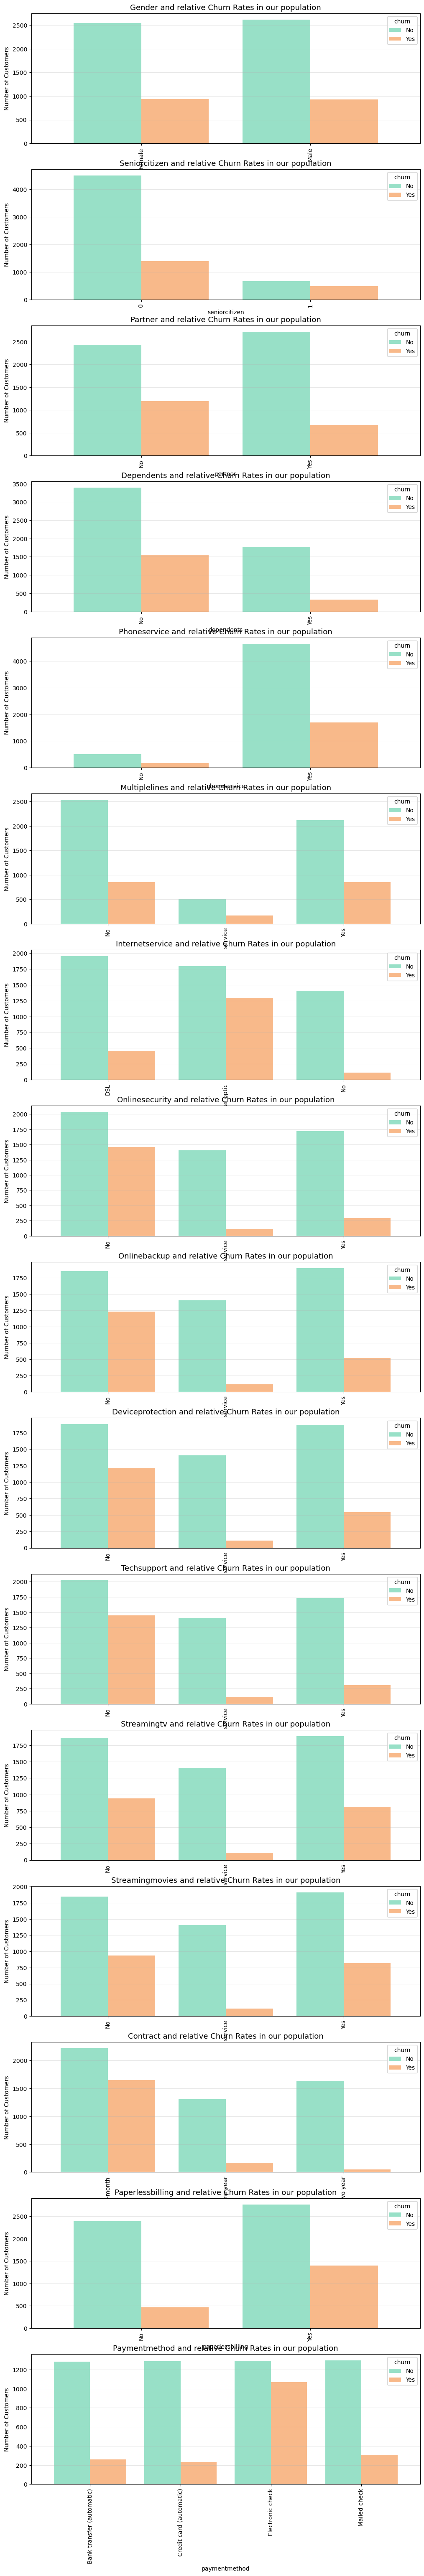

In [56]:
import matplotlib.pyplot as plt
# Create subplots
fig, axes = plt.subplots(nrows=len(cat_cols), ncols=1, figsize=(12, 4.8 * len(cat_cols)))

for ax, col in zip(axes, cat_cols):
    try:
        if col not in Telco_data.columns:
            # Try case-insensitive match
            possible = [c for c in Telco_data.columns if c.lower() == col.lower()]
            if possible:
                col = possible[0]
            else:
                ax.set_title(f"Column '{col}' NOT FOUND")
                continue
        
        # Create crosstab
        crosstab = pd.crosstab(index=Telco_data[col], columns=Telco_data['churn'])
        
        # Plot
        crosstab.plot(kind='bar', color=['#98E0C7', '#F8B98A'], ax=ax, width=0.8)
        
        ax.set_title(f'{col.capitalize()} and relative Churn Rates in our population', fontsize=13)
        ax.set_xlabel(col)
        ax.set_ylabel('Number of Customers')
        ax.legend(title='churn', labels=['No', 'Yes'])
        ax.grid(axis='y', alpha=0.3)
        
    except Exception as e:
        ax.set_title(f"Error with '{col}': {str(e)[:80]}")
        print(f"Error plotting {col}: {e}")
plt.show()

In [ ]:
'''
From the graph anaysis:
Gender: it seems to be an equal distribution of males and females with respect to churn intention (guess that gender is not important feature)

Senior citizen: There are much fewer senior citizens and there is a larger proportion of senior citizens churning. In the churn plot shows more young people are churning. (can be important)

Partner: People with partners and without partners have almost the same distribution of not churning, single people have more intention to churn. (can be important)

Dependents: There are much fewer people with dependents, there is a larger proportion of people with no dependents churning (looks like an important feature)

Phone Service: There are many more people with a phone service, almost the same intention of churn with people having phone service. (it should be important feature, but we need more explore it)

Multiple Lines: The numbers of people who have and do not have multiple lines are almost the same with respect to churn intention.(not important, but should be explore with partner and dependent)

Internet Service: There are many more people who have an internet service either with DSL or fiber, but there is a large proportion of people with fiber optic internet service who churn. (can expect that it is going to be an important prediction feature especially with Fiber Optic)

Online Security: there are more people with no online security and a larger proportion of the people has online security, has not churned. (customers having online security tend to stay within company compared to customers without online security) 

Online Backup: There are more people with no online backup and those who has online backup has less probability of churn (customers having OnlineBackup tend to stay within company compared to customers without OnlineBackup)

Device Protection: There are more people with no device protection and those who have DeviceProtection has less probability to churn.(the same with previous)

Tech Support: there are more people with no tech support and those who have tech support have less probability to churn.(the same with previous)

Streaming TV: it seems to be almost an equal distribution of people who did and did not have streaming tv with respect to churn intention.

Streaming Movies: there are more people with no streaming movies and those who have streaming movies have more probability to churn.

Contract: There are many more people who are on a month-to-month contract and a large proportion of this group of people has churned. People with one year contracts are less churn. People with two years contracts are the least people may churn.(is one of the most important feature)

Paperless Billing: The number of people with paperless billing has quite larger proportion in people who has churned

PaymentMethod: There are more people adopting electronic check as a payment method and a large proportion of them have churned.

Conclusion, based on our analyses, we can see the more services added the less people churn. Gender is not a feature, phone service and multiple lines aren't service.

'''

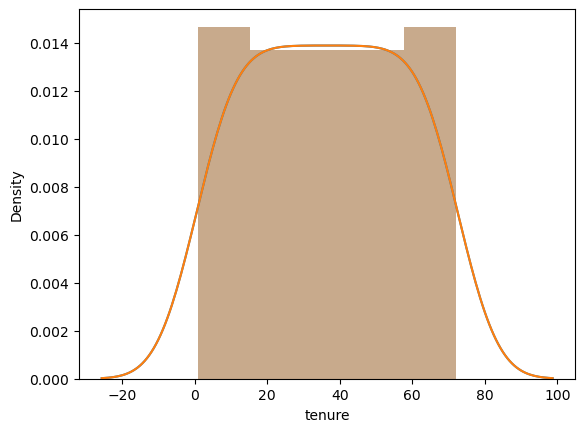

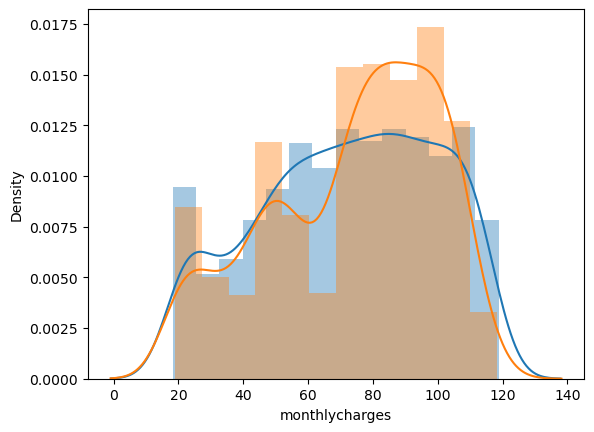

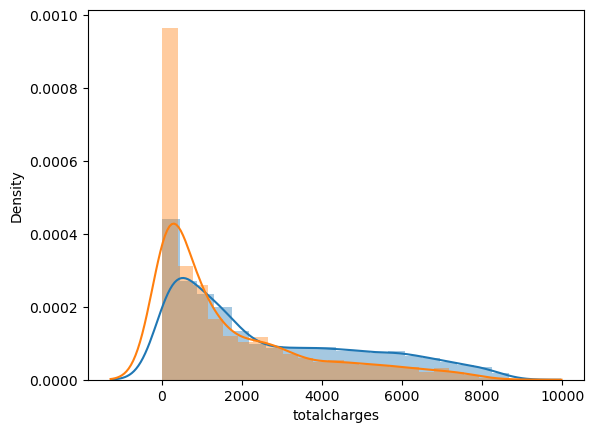

In [57]:
# exploring the churn rate by tenure, seniority, contract type, monthly charges and total charges to see how it varies by these variables.

for col in numeric_cols: 
    gb = Telco_data.groupby(col)["churn"].value_counts().to_frame().rename({"churn": "Number of Customers"}, axis = 1).reset_index()
    gb1 = gb.loc[gb["churn"]=="No"]
    gb2 = gb.loc[gb["churn"]=="Yes"]
    sns.distplot(gb1[col])
    sns.distplot(gb2[col])
    plt.show() 

<Figure size 1500x1000 with 0 Axes>

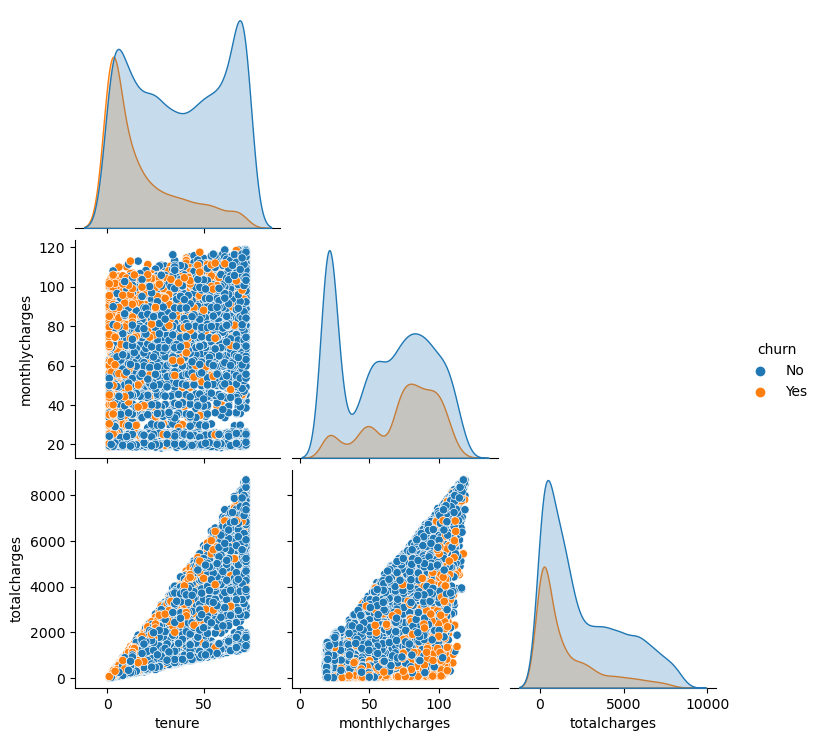

In [58]:
# for better wiew we compare this graphs by pairplot
plt.figure(figsize=(15, 10))
sns.pairplot(Telco_data, vars=['tenure', 'monthlycharges', 'totalcharges'], 
             hue='churn', diag_kind='kde',corner=True)
plt.show()

tenure            2
monthlycharges    1
totalcharges      2
dtype: int64


(<AxesSubplot:>, None)

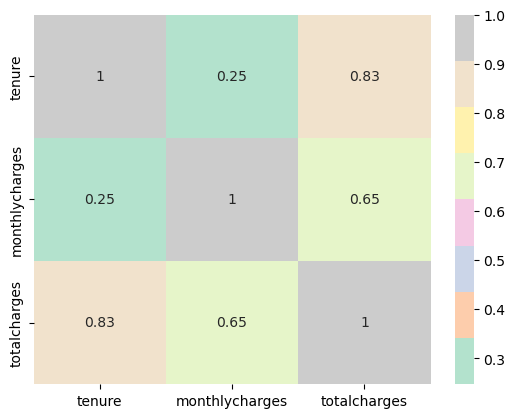

In [59]:
#make_heatmap(df, ['tenure', 'monthlycharges', 'totalcharges'])
sns.heatmap(Telco_data[['tenure', 'monthlycharges', 'totalcharges']].corr(),annot=True,cmap='Pastel2'),print(abs(Telco_data[['tenure', 'monthlycharges', 'totalcharges']].corr()>.75).sum())

In [ ]:
'''
Made heatmap of the numerical columns, it shows multicollinearity.
Total Charges and tenure columns has strong multicollinearity (over 0.80).
Total Charges and Monthly Charges correlated too (65%). We should think about this correlation before modeling.
'''

<Figure size 1500x1000 with 0 Axes>

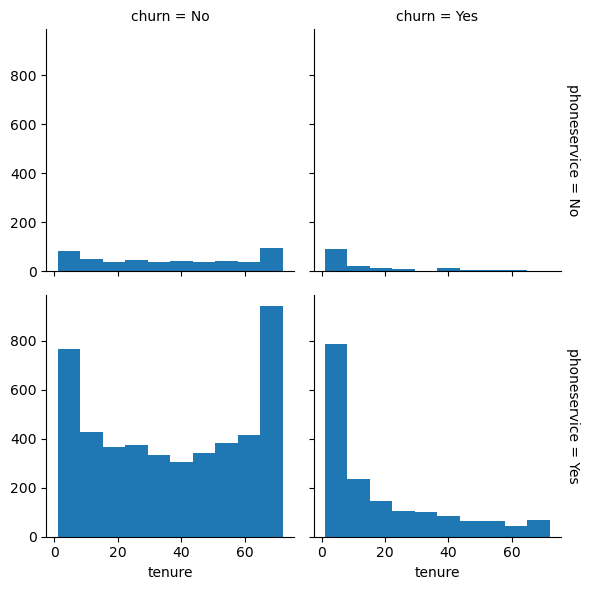

In [60]:
plt.figure(figsize=(15,10))
g = sns.FacetGrid(Telco_data, col='churn', row='phoneservice', margin_titles=True)
g.map(plt.hist, 'tenure')
plt.show()

In [61]:
# Can we create column Family where partner == YES and dependent == YES
Telco_data["huge_family"] = np.where(((Telco_data["partner"]=='Yes') & (Telco_data["dependents"]=='Yes')),1,0)
Telco_data[Telco_data["huge_family"]==1]

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,...,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,streaming,huge_family
10,Male,0,Yes,Yes,13,Yes,No,DSL,Yes,No,...,No,No,Month-to-month,Yes,Mailed check,49.95,587.45,No,No,1
15,Female,0,Yes,Yes,69,Yes,Yes,Fiber optic,Yes,Yes,...,Yes,Yes,Two year,No,Credit card (automatic),113.25,7895.15,No,Yes,1
18,Female,0,Yes,Yes,10,Yes,No,DSL,No,No,...,No,No,Month-to-month,No,Credit card (automatic),55.20,528.35,Yes,No,1
24,Male,0,Yes,Yes,49,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,No,Credit card (automatic),59.60,2970.30,No,No,1
26,Male,0,Yes,Yes,47,Yes,Yes,Fiber optic,No,Yes,...,Yes,Yes,Month-to-month,Yes,Electronic check,99.35,4749.15,Yes,Yes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7007,Male,0,Yes,Yes,1,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Mailed check,70.65,70.65,Yes,No,1
7009,Male,0,Yes,Yes,12,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,Month-to-month,Yes,Electronic check,19.20,239.00,No,No,1
7027,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,...,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,Yes,1
7028,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,...,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,Yes,1


In [62]:
# Missing values (Null/NaN)
Telco_data.isnull().sum(axis = 0)

gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
streaming           0
huge_family         0
dtype: int64

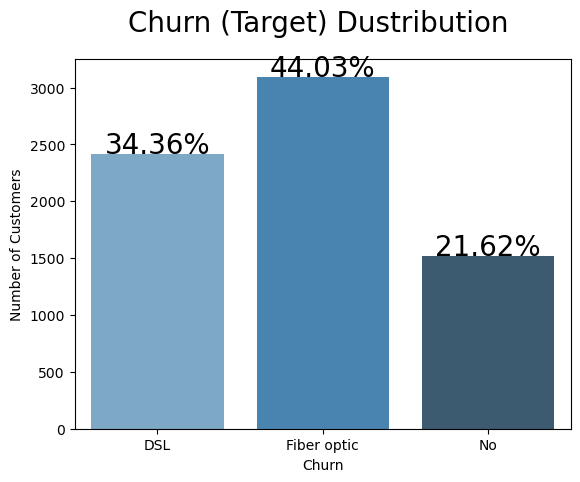

In [63]:
# one person per row
total = float(len(Telco_data))  
ax = sns.countplot(x='internetservice', data=Telco_data,  palette="Blues_d")
ax.set(xlabel='Churn',ylabel='Number of Customers')
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x()+p.get_width()/2.,
            height+3,
            '{:1.2f}'.format((height/total*100))+ '%',
            ha="center",fontsize=20) 
plt.title(("Churn (Target) Dustribution "), fontsize = 20, pad =20)
plt.show()

<AxesSubplot:xlabel='churn', ylabel='count'>

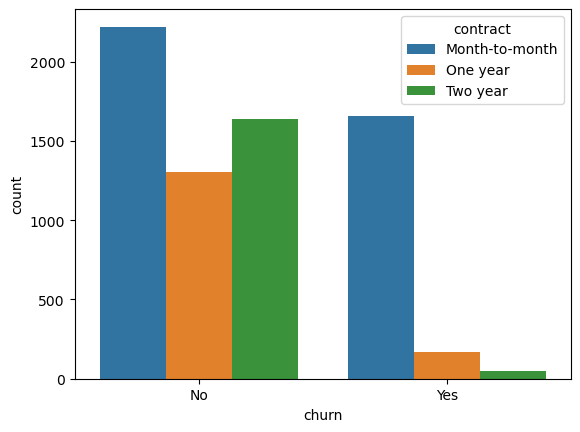

In [64]:
sns.countplot(x="churn", hue="contract", data=Telco_data)

In [65]:
# read dataset
Telco_data = pd.read_csv("clean_churn.csv")
Telco_data.head(3)

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [66]:
# Encode churn column safely
Telco_data['churn'] = Telco_data['churn'].astype(str).str.strip().str.title()

Telco_data['churn'] = Telco_data['churn'].map({'Yes': 1, 'No': 0}).astype(int)

print("\nValue Counts:")
print(Telco_data['churn'].value_counts())
print("\nFirst 5 values of churn:")
print(Telco_data['churn'].head())



Value Counts:
0    5163
1    1869
Name: churn, dtype: int64

First 5 values of churn:
0    0
1    0
2    1
3    0
4    1
Name: churn, dtype: int32


Text(0.5, 1.0, 'Count of  Customers by their tenure')

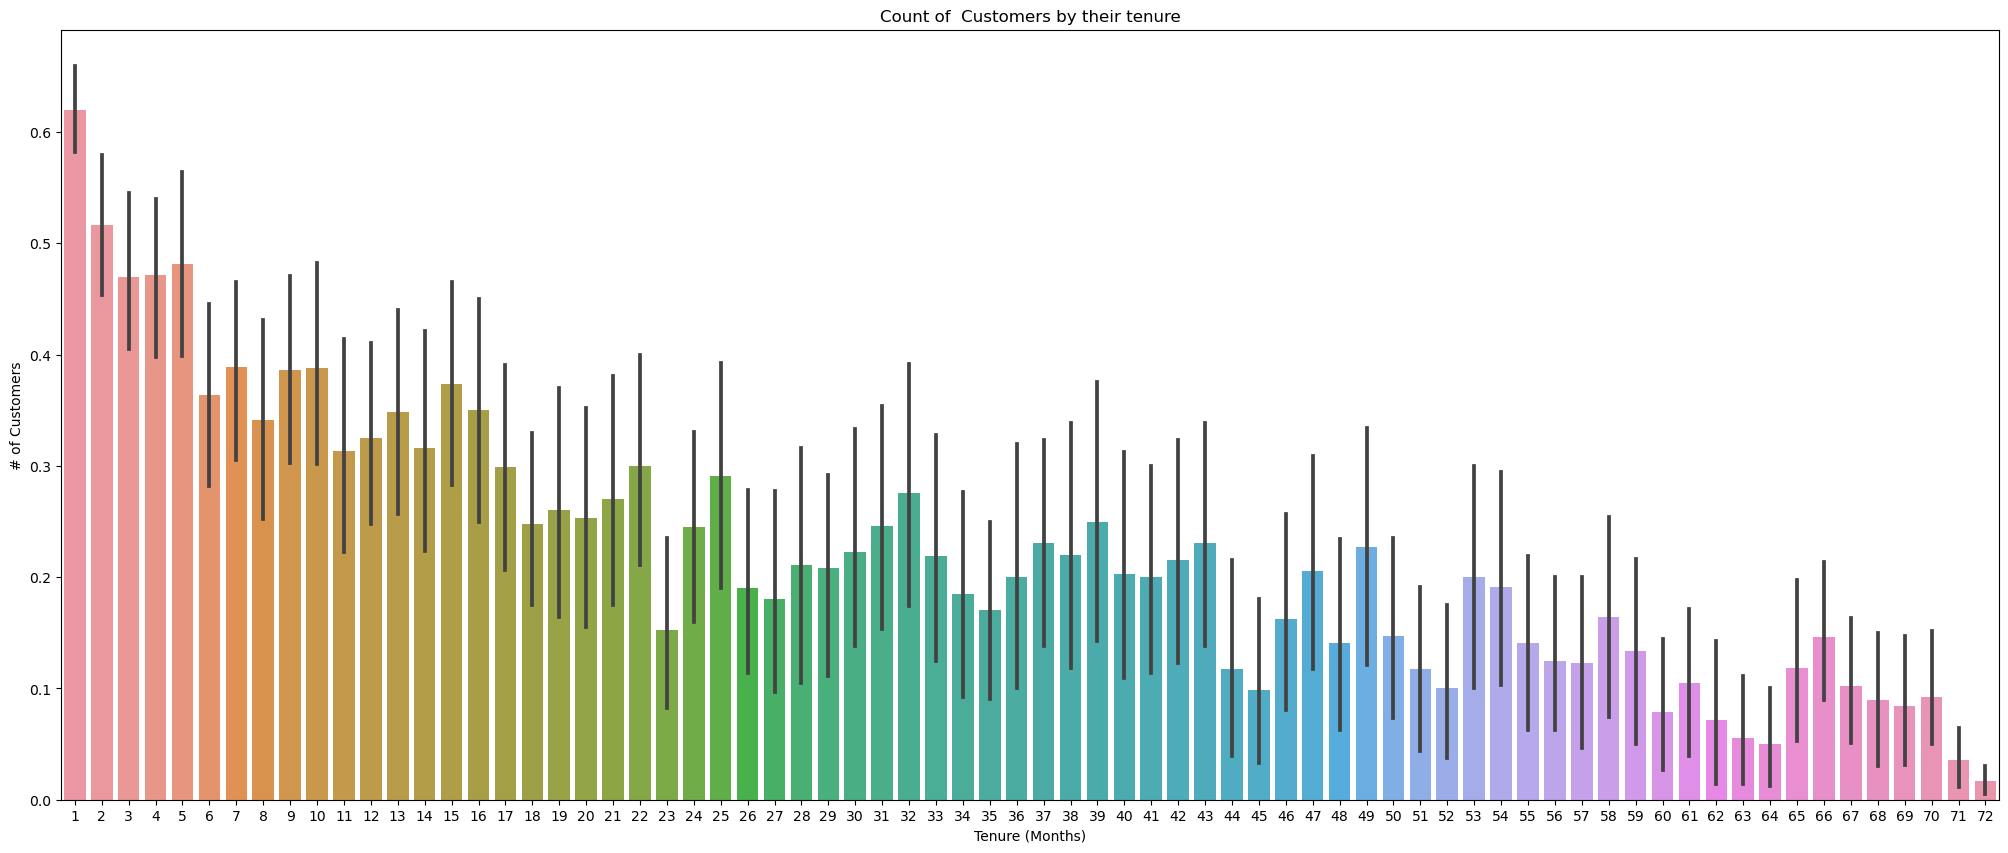

In [67]:
plt.figure(figsize=(25,10))

ax = sns.barplot(Telco_data.tenure, Telco_data.churn)
ax.set_ylabel("# of Customers")
ax.set_xlabel("Tenure (Months)")
ax.set_title("Count of  Customers by their tenure")

In [68]:
# Demographic columns: gender
Telco_data['gender'].value_counts(normalize=True)

Male      0.504693
Female    0.495307
Name: gender, dtype: float64

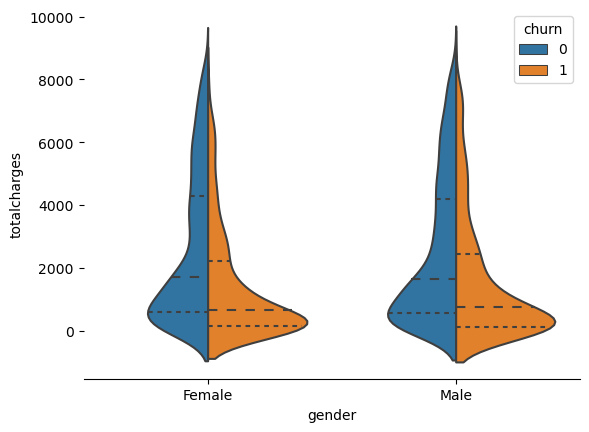

In [69]:
# Draw a nested violinplot and split the violins for easier comparison
sns.violinplot(x="gender", y="totalcharges", hue="churn",
               split=True, inner="quart",
               #palette={"Yes": "Yes", "No": "No"},
               data=Telco_data)
sns.despine(left=True)

In [70]:
# Gender column has almost equal values of churn and not churn. It doesn't give information about the possibility if a customer is likely to churn. I decide to drop this column.

Telco_data = Telco_data.drop(['gender'], axis=1)

In [71]:
n_by_state = Telco_data.groupby("tenure").count()
n_by_state.head(10)

,seniorcitizen,partner,dependents,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
tenure,,,,,,,,,,,,,,,,,,
1,613,613,613,613,613,613,613,613,613,613,613,613,613,613,613,613,613,613
2,238,238,238,238,238,238,238,238,238,238,238,238,238,238,238,238,238,238
3,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200
4,176,176,176,176,176,176,176,176,176,176,176,176,176,176,176,176,176,176
5,133,133,133,133,133,133,133,133,133,133,133,133,133,133,133,133,133,133
6,110,110,110,110,110,110,110,110,110,110,110,110,110,110,110,110,110,110
7,131,131,131,131,131,131,131,131,131,131,131,131,131,131,131,131,131,131
8,123,123,123,123,123,123,123,123,123,123,123,123,123,123,123,123,123,123
9,119,119,119,119,119,119,119,119,119,119,119,119,119,119,119,119,119,119


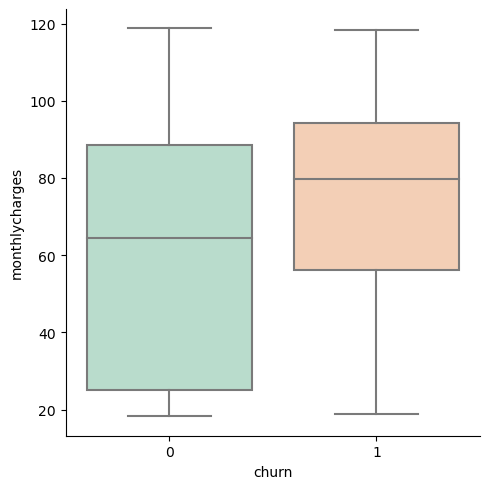

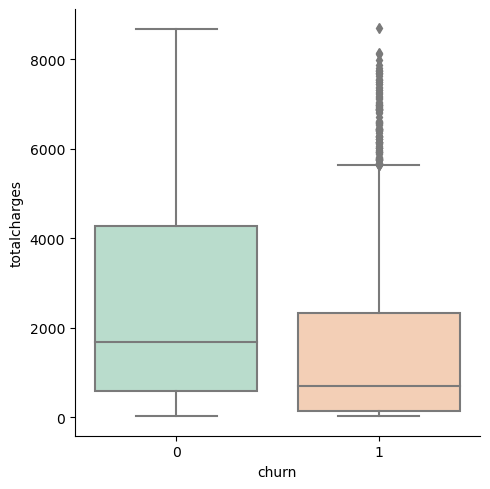

In [72]:
g = sns.catplot(x="churn", y = "monthlycharges",data = Telco_data, kind="box", palette = "Pastel2")
g = sns.catplot(y="totalcharges",x="churn",data=Telco_data,kind="box", palette = "Pastel2")

In [ ]:
'''
From boxen plot, most of churn customer has less than 2000 in total chrage. 
In range of 2500 to 8000, population of loyalty customer is around twice as amount as churn customer.
Like in 'StreamingMovies' and 'StreamingTV' these two columns are almost the same. 
I am going to drop 'OnlineSecurity' colum

'''

In [73]:
Telco_data.onlinesecurity.value_counts(normalize=True)

No                     0.497298
Yes                    0.286547
No internet service    0.216155
Name: onlinesecurity, dtype: float64

In [74]:
Telco_data.techsupport.value_counts(normalize=True)

No                     0.493743
Yes                    0.290102
No internet service    0.216155
Name: techsupport, dtype: float64

In [76]:
Telco_data[Telco_data['churn'] == 'Yes'].onlinesecurity.value_counts(normalize=True)
Telco_data[Telco_data['churn'] == 'No'].onlinesecurity.value_counts(normalize=True)
Telco_data[Telco_data['churn'] == 'Yes'].techsupport.value_counts(normalize=True)
Telco_data[Telco_data['churn'] == 'No'].techsupport.value_counts(normalize=True)

Series([], Name: techsupport, dtype: float64)

In [77]:
Telco_data.columns

Index(['seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice',
       'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup',
       'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies',
       'contract', 'paperlessbilling', 'paymentmethod', 'monthlycharges',
       'totalcharges', 'churn'],
      dtype='object')

In [78]:

# replace for one column streming
Telco_data.drop(['streamingmovies'], axis=1, inplace=True)
# after research we can drop
Telco_data = Telco_data.drop(['phoneservice'], axis=1)
# drop OnlineSecurity
Telco_data = Telco_data.drop(['onlinesecurity'], axis=1)

In [79]:
Telco_data.head()

,seniorcitizen,partner,dependents,tenure,multiplelines,internetservice,onlinebackup,deviceprotection,techsupport,streamingtv,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,0,Yes,No,1,No phone service,DSL,Yes,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,0,No,No,34,No,DSL,No,Yes,No,No,One year,No,Mailed check,56.95,1889.50,0
2,0,No,No,2,No,DSL,Yes,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,0,No,No,45,No phone service,DSL,No,Yes,Yes,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,0,No,No,2,No,Fiber optic,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [80]:
Telco_data.to_csv("mod_churn.csv", index=False)

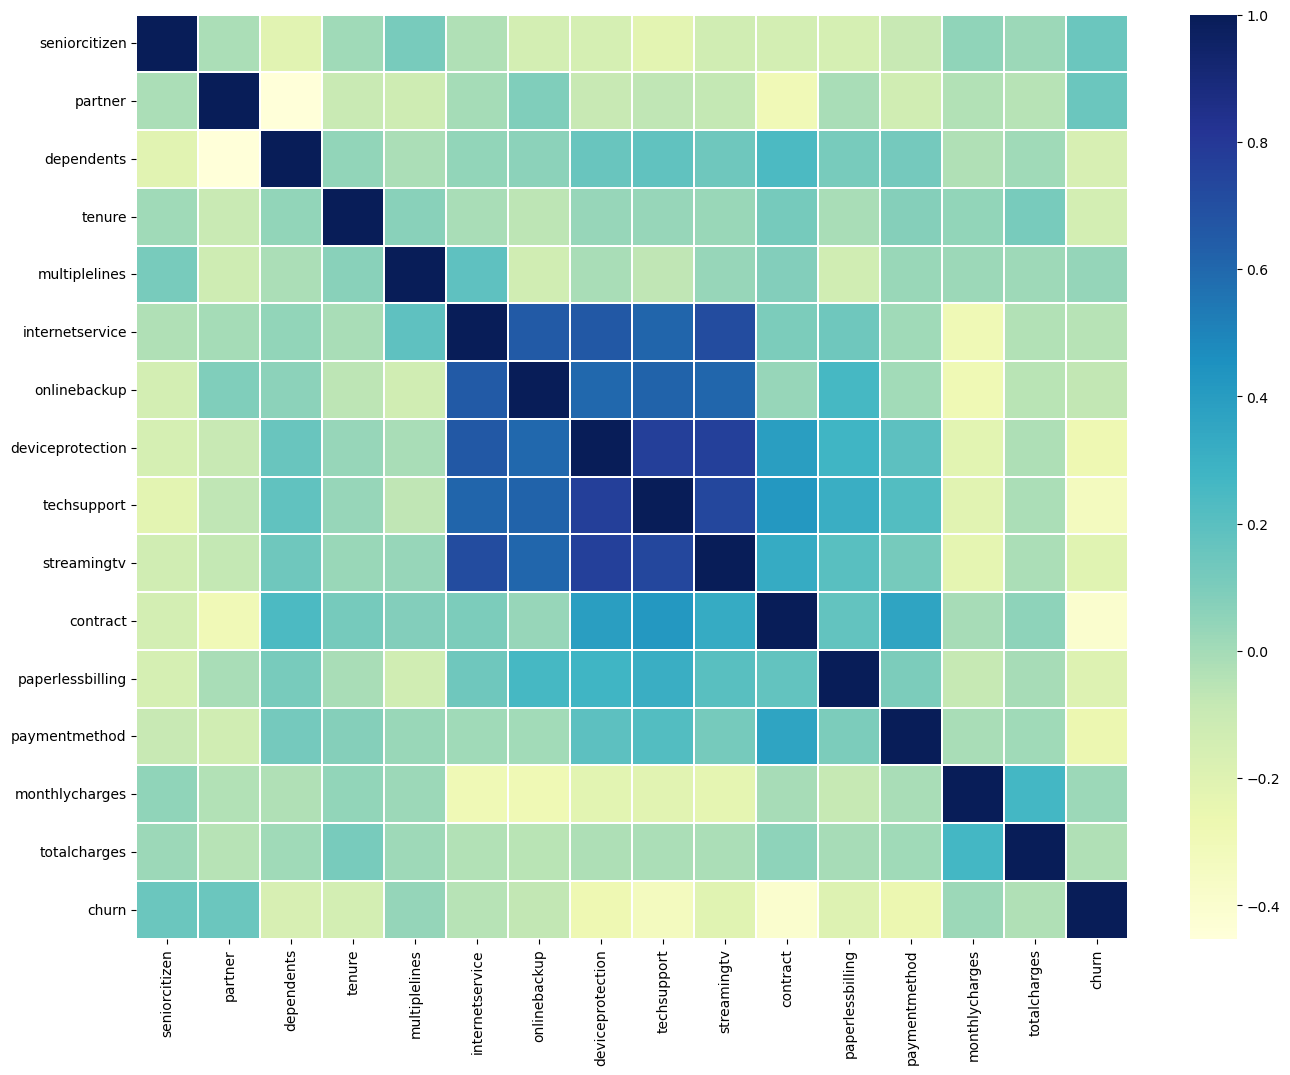

In [81]:
plt.figure(figsize=(16, 12))
corr = Telco_data.apply(lambda x: pd.factorize(x)[0]).corr()
ax = sns.heatmap(corr, xticklabels=corr.columns, yticklabels=corr.columns,
                 linewidths=.2, cmap="YlGnBu")

In [ ]:
# Prepare data for modeling:

In [82]:
# for modeling
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import precision_recall_curve,roc_auc_score,roc_curve, auc, accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, accuracy_score, f1_score
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.metrics import plot_confusion_matrix
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn import metrics
from sklearn.ensemble import AdaBoostClassifier

In [83]:
# read dataset
Telco_data = pd.read_csv("mod_churn.csv")
Telco_data.head(3)

,seniorcitizen,partner,dependents,tenure,multiplelines,internetservice,onlinebackup,deviceprotection,techsupport,streamingtv,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,0,Yes,No,1,No phone service,DSL,Yes,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,0,No,No,34,No,DSL,No,Yes,No,No,One year,No,Mailed check,56.95,1889.50,0
2,0,No,No,2,No,DSL,Yes,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


In [84]:
#1. List of Columns for modelling
print('List of columns for modeling:')
list(Telco_data.columns)

List of columns for modeling:


['seniorcitizen',
 'partner',
 'dependents',
 'tenure',
 'multiplelines',
 'internetservice',
 'onlinebackup',
 'deviceprotection',
 'techsupport',
 'streamingtv',
 'contract',
 'paperlessbilling',
 'paymentmethod',
 'monthlycharges',
 'totalcharges',
 'churn']

In [85]:
#2. One hot encoding: To prepare the dataset for modeling, encoding categorical features to numbers. 
#This means encoding "Yes"/"No" to 0/1
# One-hot encode
Telco_data = pd.get_dummies(Telco_data, 
                    columns=['seniorcitizen', 'partner', 'dependents',
                             'multiplelines', 'internetservice', 'onlinebackup', 'deviceprotection',
                             'techsupport', 'streamingtv', 'contract', 'paperlessbilling', 'paymentmethod'], 
                    drop_first=True)
Telco_data.head()

,tenure,monthlycharges,totalcharges,churn,seniorcitizen_1,partner_Yes,dependents_Yes,multiplelines_No phone service,multiplelines_Yes,internetservice_Fiber optic,...,techsupport_No internet service,techsupport_Yes,streamingtv_No internet service,streamingtv_Yes,contract_One year,contract_Two year,paperlessbilling_Yes,paymentmethod_Credit card (automatic),paymentmethod_Electronic check,paymentmethod_Mailed check
0,1,29.85,29.85,0,0,1,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0
1,34,56.95,1889.50,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,2,53.85,108.15,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
3,45,42.30,1840.75,0,0,0,0,1,0,0,...,0,1,0,0,1,0,0,0,0,0
4,2,70.70,151.65,1,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,1,0


In [86]:
list(Telco_data.columns)

['tenure',
 'monthlycharges',
 'totalcharges',
 'churn',
 'seniorcitizen_1',
 'partner_Yes',
 'dependents_Yes',
 'multiplelines_No phone service',
 'multiplelines_Yes',
 'internetservice_Fiber optic',
 'internetservice_No',
 'onlinebackup_No internet service',
 'onlinebackup_Yes',
 'deviceprotection_No internet service',
 'deviceprotection_Yes',
 'techsupport_No internet service',
 'techsupport_Yes',
 'streamingtv_No internet service',
 'streamingtv_Yes',
 'contract_One year',
 'contract_Two year',
 'paperlessbilling_Yes',
 'paymentmethod_Credit card (automatic)',
 'paymentmethod_Electronic check',
 'paymentmethod_Mailed check']

In [87]:
Telco_data.shape

(7032, 25)

In [97]:
#Create a baseline model
# Splitting the data into test and train sets
X = Telco_data.drop(['churn'], axis=1)
y = Telco_data['churn']

In [98]:
# Split data into X and y
y=Telco_data['churn'].copy()

# Define X
X = Telco_data.drop(columns=['churn'], axis=1)

# Split the data into a training and a test set and set stratify=y to help with imbalance data
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [ ]:
#Decision Tree

In [135]:
# modeling with Decision Tree
#create an instance and fit the model 
treemodel = DecisionTreeClassifier(random_state=123)
treemodel.fit(X_train, y_train)

#predictions
y_hat_train= treemodel.predict(X_train)
y_hat_test = treemodel.predict(X_test)

# Evaluate predictions
print('Accuracy score for Training Dataset = ', accuracy_score(y_train, y_hat_train))
print('Accuracy score for Testing Dataset = ', accuracy_score(y_test, y_hat_test))
print('Confusion Matrix')
print('Train set:')
print(confusion_matrix(y_train, y_hat_train), '\n')
print('Test set:')
print(confusion_matrix(y_test, y_hat_test), '\n')
print('Classification Matrix:')
print(classification_report(y_test, y_hat_test))

Accuracy score for Training Dataset =  0.9973333333333333
Accuracy score for Testing Dataset =  0.7292110874200426
Confusion Matrix
Train set:
[[4126    4]
 [  11 1484]] 

Test set:
[[839 194]
 [187 187]] 

Classification Matrix:
              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1033
           1       0.49      0.50      0.50       374

    accuracy                           0.73      1407
   macro avg       0.65      0.66      0.66      1407
weighted avg       0.73      0.73      0.73      1407



In [134]:
'''
Accuracy score for Training Dataset = 0.9975 >> then Accuracy score for Testing Dataset = 0.7298
It show us oversampling
'''

'\nAccuracy score for Training Dataset = 0.9975 >> then Accuracy score for Testing Dataset = 0.7298\nIt show us oversampling\n'

In [ ]:
#Random Forest

In [138]:
def evaluate_predictions(X_train, X_test, y_train, y_test, y_hat_train, y_hat_test):
    print("--- TRAINING SET PERFORMANCE ---")
    print(f"Accuracy: {accuracy_score(y_train, y_hat_train):.4f}")
    print(classification_report(y_train, y_hat_train))
    
    print("\n--- TEST SET PERFORMANCE ---")
    print(f"Accuracy: {accuracy_score(y_test, y_hat_test):.4f}")
    print(classification_report(y_test, y_hat_test))

#SPLIT dataset
X = Telco_data.drop(['churn'], axis=1)
y = Telco_data['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Calling
scaler = StandardScaler()
# We fit on train and transform both
scaled_X_train_arr = scaler.fit_transform(X_train)
scaled_X_test_arr = scaler.transform(X_test)

# Convert back to DataFrames to keep column names for feature importance
scaled_X_train = pd.DataFrame(scaled_X_train_arr, columns=X_train.columns)
scaled_X_test = pd.DataFrame(scaled_X_test_arr, columns=X_test.columns)
# Using class_weight='balanced' handles the imbalance
randommodel = RandomForestClassifier(
    max_depth=5, 
    n_jobs=-1, 
    class_weight='balanced', 
    random_state=42
)

# Use the SCALED data here
randommodel.fit(scaled_X_train, y_train)

# EVALUATION
evaluate_predictions(scaled_X_train, scaled_X_test, y_train, y_test, y_hat_train, y_hat_test)

--- TRAINING SET PERFORMANCE ---
Accuracy: 0.9973
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4130
           1       1.00      0.99      0.99      1495

    accuracy                           1.00      5625
   macro avg       1.00      1.00      1.00      5625
weighted avg       1.00      1.00      1.00      5625


--- TEST SET PERFORMANCE ---
Accuracy: 0.7292
              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1033
           1       0.49      0.50      0.50       374

    accuracy                           0.73      1407
   macro avg       0.65      0.66      0.66      1407
weighted avg       0.73      0.73      0.73      1407



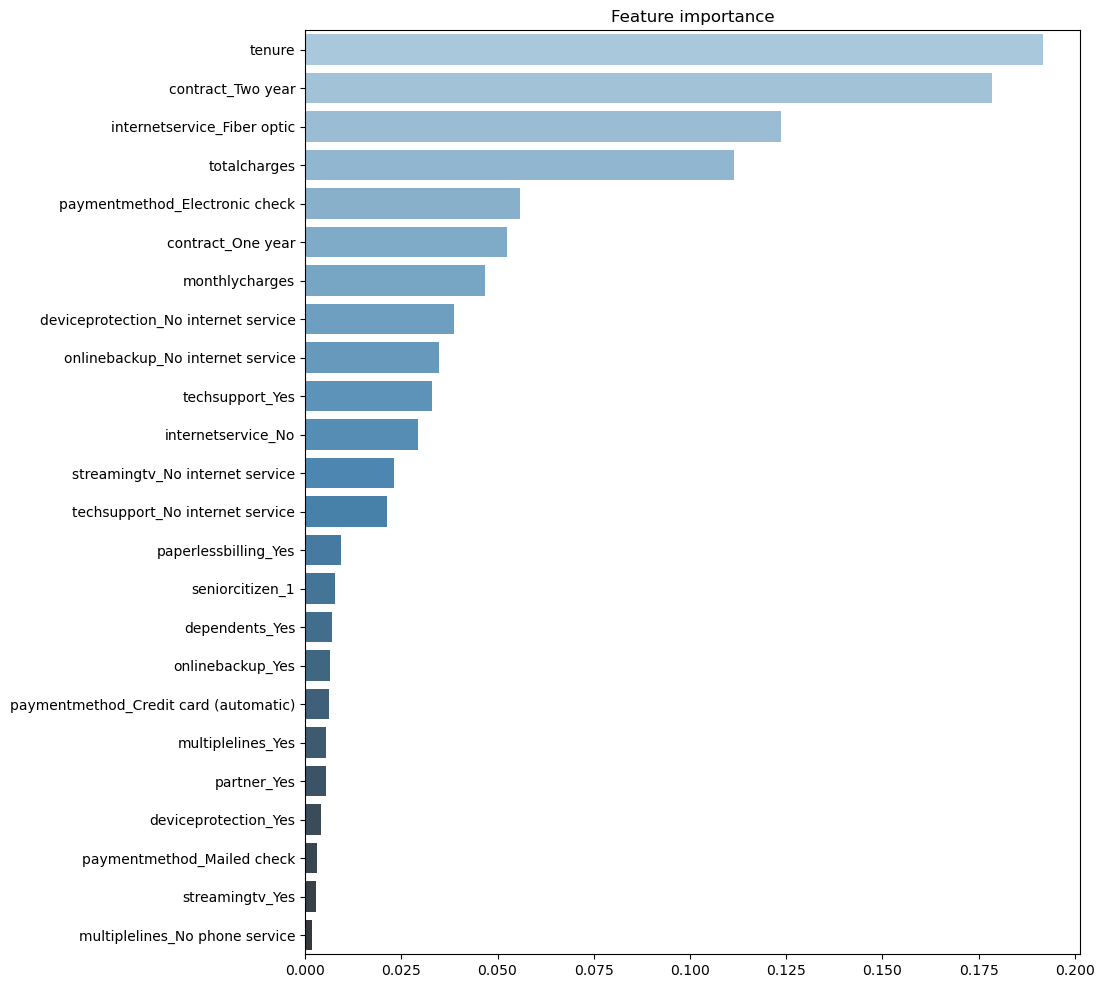

In [139]:
# Plot features importances
imp = pd.Series(data=randommodel.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,12))
plt.title("Feature importance")
ax = sns.barplot(y=imp.index, x=imp.values, palette="Blues_d", orient='h')

Text(0, 0.5, 'Feature')

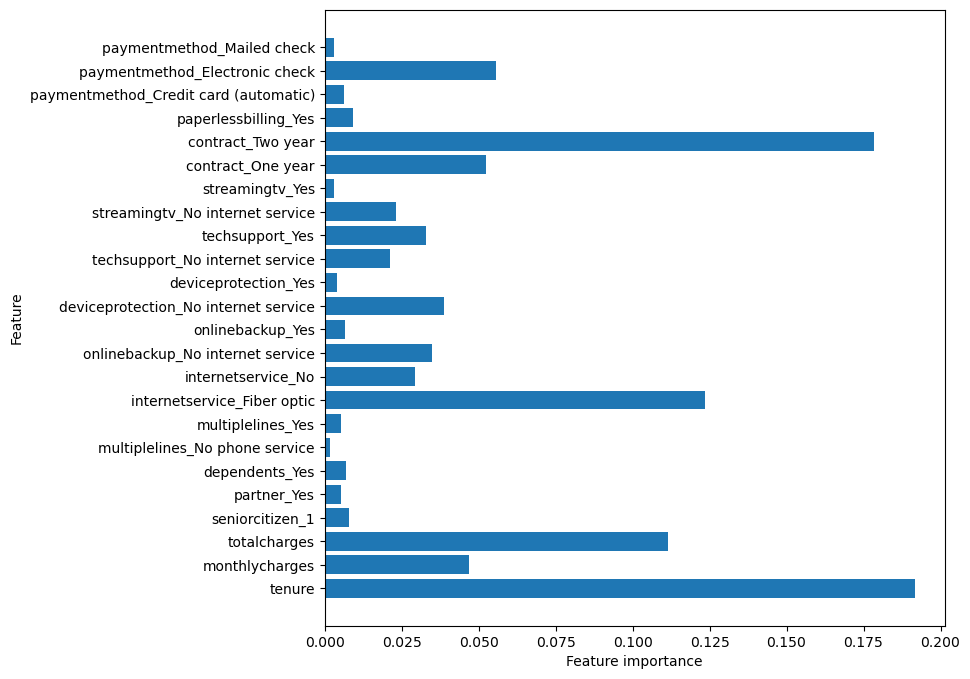

In [140]:
n_features = X_train.shape[1]
plt.figure(figsize=(8, 8))
plt.barh(range(n_features), randommodel.feature_importances_, align='center')
plt.yticks(np.arange(n_features), X_train.columns.values)
plt.xlabel('Feature importance')
plt.ylabel('Feature')

In [ ]:
# from the above graph; Most important features: tenure, Contract Two Year, Internet Service FiberOptic, and Total Charges.

In [ ]:
'''
Conclusions
I have a precision of 0.49 (it means 49% of the customers we say 'churn' was true) and recall of 0.79 in the test set for this model.
It shows no over fitting.
'''

In [ ]:
# Tuning For Hyperparameters By Grid Search

In [ ]:
# SVM (Support Vector Classification)

In [146]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)


In [145]:
# use grid search and class_weight = 'balanced'
param_grid = {'C': [0.1, 1, 10, 100, 1000],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
              # use gamma which works only with this tree kernel
              #'kernel': ['poly', 'rbf', 'sigmoid'] 
              'kernel':['rbf']
             }

svm = GridSearchCV(SVC(class_weight = 'balanced'), param_grid, refit=True)

svm.fit(scaled_X_train, y_train)
y_hat_train = svm.predict(scaled_X_train)
y_hat_test = svm.predict(scaled_X_test)
svm.best_params_

{'C': 0.1, 'gamma': 1, 'kernel': 'rbf'}

In [147]:
evaluate_predictions(X_train, X_test, y_train, y_test, y_hat_train, y_hat_test)

--- TRAINING SET PERFORMANCE ---
Accuracy: 0.7924
              precision    recall  f1-score   support

           0       0.81      0.95      0.87      4130
           1       0.71      0.37      0.49      1495

    accuracy                           0.79      5625
   macro avg       0.76      0.66      0.68      5625
weighted avg       0.78      0.79      0.77      5625


--- TEST SET PERFORMANCE ---
Accuracy: 0.7662
              precision    recall  f1-score   support

           0       0.79      0.94      0.85      1033
           1       0.63      0.30      0.40       374

    accuracy                           0.77      1407
   macro avg       0.71      0.62      0.63      1407
weighted avg       0.74      0.77      0.73      1407



In [148]:
print(svm.score(X_train, y_train))
print(svm.score(X_test, y_test))

0.7342222222222222
0.7341862117981521


In [ ]:
#Interpreting the results of the SVM model
#We have a precision of 0.65 and recall of 0.30 in the test set.

Accuracy: 0.7910447761194029 

tenure                                   0.213840
monthlycharges                           0.082120
totalcharges                             0.137229
seniorcitizen_1                          0.010900
partner_Yes                              0.006009
dependents_Yes                           0.007333
multiplelines_No phone service           0.003270
multiplelines_Yes                        0.008334
internetservice_Fiber optic              0.118291
internetservice_No                       0.021691
onlinebackup_No internet service         0.019776
onlinebackup_Yes                         0.010079
deviceprotection_No internet service     0.022188
deviceprotection_Yes                     0.005344
techsupport_No internet service          0.023611
techsupport_Yes                          0.036356
streamingtv_No internet service          0.023074
streamingtv_Yes                          0.005761
contract_One year                        0.045851
contract_Two year  

<AxesSubplot:>

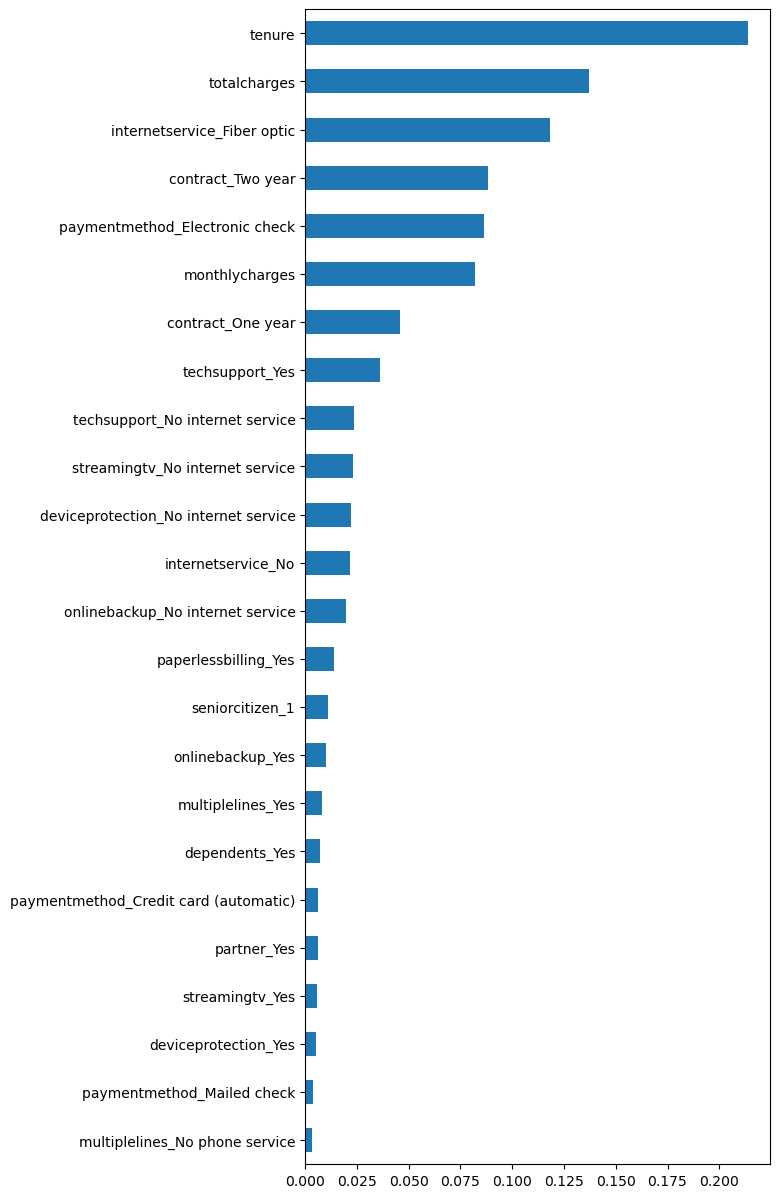

In [149]:
rf = RandomForestClassifier(n_estimators=1000,
                            oob_score = True,
                            n_jobs = -1,
                            random_state =50,
                            max_features = "auto",
                            max_leaf_nodes = 30)
rf.fit(X_train, y_train)

# Make predictions
pred_rf = rf.predict(X_test)
print('Accuracy:', metrics.accuracy_score(y_test, pred_rf), '\n')
importances = rf.feature_importances_
weights_RanFor = pd.Series(importances,
                 index=X.columns.values)
print(weights_RanFor)
plt.figure(figsize=(6, 15))
weights_RanFor.sort_values().plot(kind = 'barh')

In [ ]:
'''
From random forest algorithm, monthly contract, tenure and total charges are the most important predictor variables to predict churn. 
The results from random forest and in line to what we had expected from our EDA

'''

In [ ]:
#QUESTION TWO REPORT

In [ ]:
'''
1. Description of the Dataset

The dataset used in this analysis is the Telco Customer Churn dataset, which contains information about customers of a telecommunications company and whether they have churned (left the company) or not obtained from Kaggle

The dataset includes the following categories of variables:
    •Demographic information: gender, senior citizen status, partner, dependents 
    •Services subscribed: phone service, internet service, online backup, streaming services, tech support, etc. 
    •Customer account information: tenure, contract type, payment method, monthly charges, and total charges 
    •Target variable- churn (Yes = customer left, No = customer stayed) 
The dataset contains both categorical and numerical features. It is also imbalanced, with approximately 74% non-churn customers and 26% churn customers, which influences model evaluation and performance.

2. Data Preprocessing

2.1 Data Cleaning
    •Converted all column names to lowercase for consistency 
    •Identified and handled missing values in the totalcharges column 
    •Replaced blank values with NaN and dropped those rows (only ~0.15%) 
    •Converted totalcharges from object to float type 
    •Removed duplicate records 

2.2 Feature Selection
    •Dropped irrelevant features such as: 
        customerid (unique identifier, no predictive value) 
    •Removed less useful or redundant features based on exploratory analysis: 
        gender, phoneservice, onlinesecurity, streamingmovies 

2.3 Feature Engineering
    •Created new feature: 
        huge_family (combining partner and dependents) 
    •Identified multicollinearity: 
        Strong correlation between tenure and totalcharges 
    •Simplified service-related features to reduce redundancy 

2.4 Encoding and Transformation
    •Converted categorical variables into numerical form using one-hot encoding 
    •Converted target variable churn into binary: Yes → 1, No → 0 

2.5 Data Splitting
    •Split the dataset into: 
        Training set 
        Testing set 
    •Used random splitting to ensure fair model evaluation 

3. Model Implementation
Three machine learning models were implemented:

3.1 Decision Tree Classifier
    •A tree-based model that splits data based on feature values 
    •Implemented using Decision Tree Classifier 
    •Trained on the training dataset without initial tuning 

3.2 Random Forest Classifier
    •An ensemble model that combines multiple decision trees 
    •Implemented using Random Forest Classifier 
    •Key parameters: 
        Number of trees (n_estimators) 
        Maximum depth (max_depth) 
    •Uses bagging to reduce overfitting 

3.3 Support Vector Machine (SVM)
    •A model that finds the optimal boundary between classes 
    •Data was standardized before training 
    •Implemented using SVC 
    •Used Grid Search CV for hyperparameter tuning 

4. Evaluation Results
The performance of each model was evaluated using Accuracy, Precision, Recall, and F1-score.

4.1 Decision Tree
    •Accuracy (Training): 99.75% 
    •Accuracy (Testing): 72.98% 
    •Precision: ~0.73 
    •Recall: ~0.73 
    •F1-Score: ~0.73 

4.2 Random Forest
    •Accuracy: ~78% 
    •Precision: 0.49 
    •Recall: 0.79 
    •F1-Score: 0.49 

4.3 Support Vector Machine (SVM)
    •Accuracy: ~73% 
    •Precision: 0.65 
    •Recall: 0.30 
    •F1-Score: ~0.41 

5. Best Performing Model

The Random Forest model performed best overall because of the following;
    •It achieved the highest recall (0.79), meaning it identified most churn customers 
    •It generalizes better than the Decision Tree (less overfitting) 
    •It balances bias and variance effectively 

Although its precision is lower, it is more important in churn prediction to identify as many potential churners as possible, even at the cost of some false positives.

6. Hyperparameter Tuning

Hyperparameter tuning was mainly applied to the SVM model using Grid Search.
Parameters tuned:
    •C (controls regularization) 
    •gamma (controls influence of data points) 
    •kernel = 'rbf' 

Effect on Performance:
    •Improved precision of the model 
    •Slight improvement in overall stability 
    •However, recall remained low, limiting effectiveness 
Further tuning could also be applied to:

    •Random Forest (depth, number of trees) 
    •Decision Tree (pruning to reduce overfitting) 

7. Bias-Variance Trade-off

•Decision Tree: 
    Low bias, high variance 
    Overfits training data 

•Random Forest: 
    Balanced bias and variance 
    Reduced overfitting through ensemble learning 
•SVM: 
    Higher bias, lower variance 
    Underfits some patterns (low recall) 
8. Reflections and Recommendations
Reflections
•Dataset imbalance significantly affected model performance 
•Feature importance analysis shows key predictors: tenure, contract type, total charges 
•Overfitting is a major issue in simple models like Decision Trees 
Recommendations
1.Handle Class Imbalance by using techniques like SMOTE or ADASYN to improve recall 
2.Improve Feature Selection by removing highly correlated variables and focusing on most important predictors 
3.Hyperparameter Optimization by tuning Random Forest and Decision Tree models further 
4.Use Advanced Models Gradient Boosting (e.g., XGBoost, AdaBoost) 
5.Focus on Recall in churn prediction, by prioritizing identification of churners over perfect accuracy 
9. Conclusion
This study applied multiple machine learning models to predict customer churn. Among the models, Random Forest achieved the best performance, particularly due to its ability to correctly identify customers at risk of leaving. While improvements can still be made, the model provides a strong foundation for practical churn prediction and customer retention strategies.
'''